# 06 - Explainability, Robustness, and Final Result Summary


> Reproducibility note: expensive training commands are shown as code or comments. For viva, these notebooks load the saved final outputs committed in the repository, so the panel can inspect the evidence without rerunning hours of training.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Works in Colab and in a local clone. In Colab, uncomment the mount lines if needed.
try:
    from google.colab import drive  # type: ignore
    # drive.mount('/content/drive')
    COLAB_ROOT = Path('/content/drive/MyDrive/fake-news-rl-fusion')
    PROJECT_ROOT = COLAB_ROOT if COLAB_ROOT.exists() else Path.cwd().resolve().parent
except Exception:
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

print('PROJECT_ROOT =', PROJECT_ROOT)

def read_json(relative_path):
    with open(PROJECT_ROOT / relative_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def read_csv(relative_path):
    return pd.read_csv(PROJECT_ROOT / relative_path)

def show_metrics(metrics, keys=('macro_f1', 'accuracy', 'roc_auc', 'balanced_accuracy')):
    rows = []
    for key in keys:
        if key in metrics:
            rows.append({'metric': key, 'value': metrics[key]})
    display(pd.DataFrame(rows))

PROJECT_ROOT = C:\Users\acer\Documents\GitHub\fake-news-rl-fusion


## Purpose
This notebook collects final explainability evidence, robustness checks, and the final comparison table for viva presentation.

In [2]:
explain = read_json('outputs/metrics/final_explainability_summary.json')
print('Explained samples:', explain.get('rows'))
print('Output directory:', explain.get('output_dir'))
samples = pd.DataFrame(explain.get('samples', []))
cols = ['sample_id', 'label', 'final_prediction', 'final_probability', 'selected_action', 'image_weight', 'text_weight', 'top_text_tokens']
display(samples[cols].head(10))

Explained samples: 16
Output directory: outputs/explainability/final


,sample_id,label,final_prediction,final_probability,selected_action,image_weight,text_weight,top_text_tokens
0,2puoj1,0,0,0.160394,2,0.60,0.40,"[spiked, oklahoma, leads, bull, mm, red, road,..."
1,c6p5hz,0,0,0.184602,1,0.75,0.25,"[pepper, looks, stitch, like, itself, it, this..."
2,c4b9wx,0,0,0.069143,1,0.75,0.25,"[skinny, egg, weird, cart, morning, found, lon..."
3,8ia8bg,0,0,0.377796,3,0.50,0.50,"[performers, these, street]"
4,1pnn72,0,0,0.028231,1,0.75,0.25,"[shaking, cat, hands, ##fish, ##aw, cr, with, a]"
5,czd1xu,0,1,0.980514,0,0.90,0.10,"[screaming, branch, hear, else, who, this, can]"
6,3pz76g,0,0,0.063070,1,0.75,0.25,"[teen, gift, deaf, giving, is, hearing, childr..."
7,5woni4,0,0,0.204114,2,0.60,0.40,"[##ma, ##own, no, restaurant, ##wash, top, be,..."
8,ayyfhu,1,1,0.880856,3,0.50,0.50,"[mustache, fancy, watching, recording, you, is..."
9,cb86b43,1,1,0.648623,3,0.50,0.50,"[discussions, other]"


In [3]:
# Display Grad-CAM examples if the image files exist in this clone/Drive.
shown = 0
for _, row in samples.head(6).iterrows():
    image_path = PROJECT_ROOT / row['image_gradcam_path']
    if image_path.exists():
        display(Markdown(f"### Sample {row['sample_id']} | label={row['label']} | prediction={row['final_prediction']} | P(fake)={row['final_probability']:.3f}"))
        display(Image(filename=str(image_path)))
        shown += 1
if shown == 0:
    print('Grad-CAM PNG files are not committed to GitHub. They exist in the Colab/Drive run under outputs/explainability/final/image_gradcam/.')

Grad-CAM PNG files are not committed to GitHub. They exist in the Colab/Drive run under outputs/explainability/final/image_gradcam/.


,corruption,modality,level,macro_f1,delta_target_weight,adapted_in_expected_direction
0,image_quality_drop,image,0.25,0.867071,-0.016402,True
1,image_quality_drop,image,0.50,0.866541,-0.063241,True
2,image_quality_drop,image,0.75,0.865757,-0.128254,True
3,text_quality_drop,text,0.25,0.867333,0.048915,False
4,text_quality_drop,text,0.50,0.867333,0.128347,False
5,text_quality_drop,text,0.75,0.867333,0.148360,False
6,image_probability_noise,image,0.10,0.862567,-0.012778,True
7,image_probability_noise,image,0.20,0.856187,-0.015450,True
8,text_probability_noise,text,0.10,0.862286,-0.003915,True
9,text_probability_noise,text,0.20,0.855117,0.004312,False


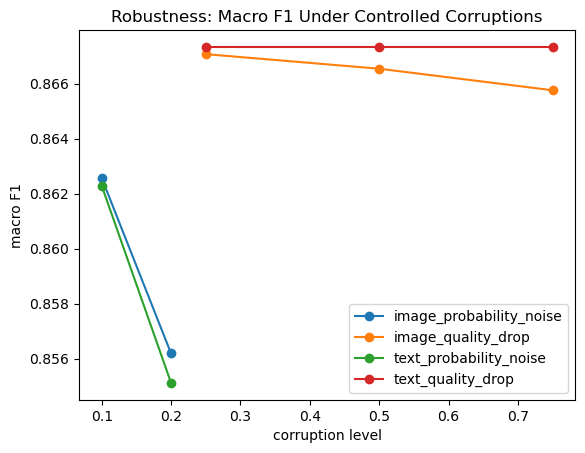

In [4]:
robust = read_csv('outputs/robustness/final_robustness_summary.csv')
display(robust[['corruption', 'modality', 'level', 'macro_f1', 'delta_target_weight', 'adapted_in_expected_direction']])
for corruption, group in robust.groupby('corruption'):
    plt.plot(group['level'], group['macro_f1'], marker='o', label=corruption)
plt.title('Robustness: Macro F1 Under Controlled Corruptions')
plt.xlabel('corruption level')
plt.ylabel('macro F1')
plt.legend()
plt.show()

In [5]:
final_methods = read_csv('outputs/tables/final_method_comparison.csv')
final_test = final_methods[final_methods['split'].eq('test')].sort_values('macro_f1', ascending=False)
display(final_test)
best = final_test.iloc[0]
print(f"Best test method: {best['method']} macro F1={best['macro_f1']:.6f}, accuracy={best['accuracy']:.6f}, ROC-AUC={best['roc_auc']:.6f}")

,source,split,method,macro_f1,accuracy,roc_auc
0,rl,test,rl_full_state,0.867604,0.867725,0.932894
1,baseline,test,equal_fusion,0.867333,0.867460,0.932542
2,baseline,test,confidence_weighted_fusion,0.867333,0.867460,0.933996
3,ablation,test,rl_full_reliability_state,0.867333,0.867460,0.932643
4,baseline,test,reliability_weighted_fusion,0.861206,0.861376,0.932866
5,ablation,test,rl_prediction_confidence,0.858994,0.858995,0.918426
6,ablation,test,rl_probabilities_only,0.852315,0.852381,0.920512
7,baseline,test,text_only,0.838769,0.838889,0.912095
8,baseline,test,image_only,0.776928,0.779101,0.857216


Best test method: rl_full_state macro F1=0.867604, accuracy=0.867725, ROC-AUC=0.932894


In [6]:
summary = read_json('outputs/tables/final_results_summary.json')
print('Missing inputs:', summary.get('missing_inputs'))
print('Policy average weights:', summary['policy_summary']['weight_summary'])
print('Oracle upper bound macro F1:', summary['policy_summary']['oracle_action_upper_bound']['macro_f1'])

Missing inputs: []
Policy average weights: {'average_image_weight': 0.6594444444444444, 'average_text_weight': 0.34055555555555556, 'image_weight_std': 0.1635889102893776, 'text_weight_std': 0.16358891028937653}
Oracle upper bound macro F1: 0.9306107315006091


In [7]:
# Reproduction commands:
# %cd /content/drive/MyDrive/fake-news-rl-fusion
# !python scripts/explain_predictions.py --config configs/final_explainability.yaml
# !python scripts/run_robustness.py --config configs/final_robustness.yaml
# !python scripts/export_results.py --config configs/final_results_export.yaml

## Viva Closing Claim
The final result supports an explainable adaptive fusion framework: the RL policy is competitive with and slightly better than fixed fusion, the policy analysis shows sample-level modality weighting, ablation supports reliability-aware state features, and explainability outputs provide Grad-CAM plus token saliency evidence.